In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import random_split

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Creación de dataset

class QRDatasetNPZ(Dataset):
    def __init__(self, img_path, resp_path):
        self.X = np.load(img_path)['arr_0'][0:50000]   # Ajusta el nombre si no es 'arr_0'
        self.Y = np.load(resp_path)['results']
        assert len(self.X) == len(self.Y), "Error: longitudes distintas"
        
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32).unsqueeze(0)  # Añadir canal
        y = torch.tensor(self.Y[idx], dtype=torch.float32)
        return x, y

# --- Uso ---
dataset = QRDatasetNPZ('../../Generacion de imagenes/images0_125.npz', '../../Resultados/Resultados0_50.npz')

# Normalizar coeficientes
dataset.Y = dataset.Y/(12e9)
mask = ~np.isnan(dataset.Y).any(axis=1)
dataset.X = dataset.X[mask]
dataset.Y = dataset.Y[mask]


dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Ejemplo rápido
for imgs, coeffs in dataloader:
    print("Batch imágenes:", imgs.shape)   # [batch, 1, 64, 64]
    print("Batch coeficientes:", coeffs.shape)  # [batch, 6]
    break

Batch imágenes: torch.Size([32, 1, 64, 64])
Batch coeficientes: torch.Size([32, 6])


In [ ]:
# Training and testing data

# 90% entrenamiento, 10% test
train_size = int(0.9 * len(dataset))
test_size  = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# CNN Creation

In [4]:
# Model Class
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,1, padding=1)
        self.conv2 = nn.Conv2d(16,32,3,1, padding=1)
        self.conv3 = nn.Conv2d(32,64,3,1, padding=1)
        # Fully connected layer
        self.fc1 = nn.Linear(64*8*8, 6) # FC(64*8*8x32)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        # Second pass
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        # Third pass
        X = F.relu(self.conv3(X))
        X = F.max_pool2d(X, 2, 2)
        # Re-View to flatten it out
        X = X.view(-1, 64*8*8) # Negative one so we can vary the batch size. # Flatten to (batch_size, 64)

        # Fully connected layers
        X = self.fc1(X)
        
        return X

# Create an Instance of our Model
torch.manual_seed(2) # A random number

## Training and Testing procces

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN()
model = model.to(device)


criterion = nn.MSELoss()           
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5
loss_history = []  # para graficar

for epoch in range(epochs):
    running_loss = 0.0

    for X_train, Y_train in train_loader:
        X_train, Y_train = X_train.to(device), Y_train.to(device)

        # Forward
        y_pred = model(X_train)
        loss = criterion(y_pred, Y_train)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.6f}")

print("Entrenamiento finalizado 🚀")

torch.save(model.state_dict(), "modelo_final.pth")
print("Modelo guardado en modelo_final.pth")

Epoch [1/5] - Loss: 0.001301
Epoch [2/5] - Loss: 0.000728
Epoch [3/5] - Loss: 0.000653
Epoch [4/5] - Loss: 0.000630
Epoch [5/5] - Loss: 0.000621
Entrenamiento finalizado 🚀
Modelo guardado en modelo_final.pth


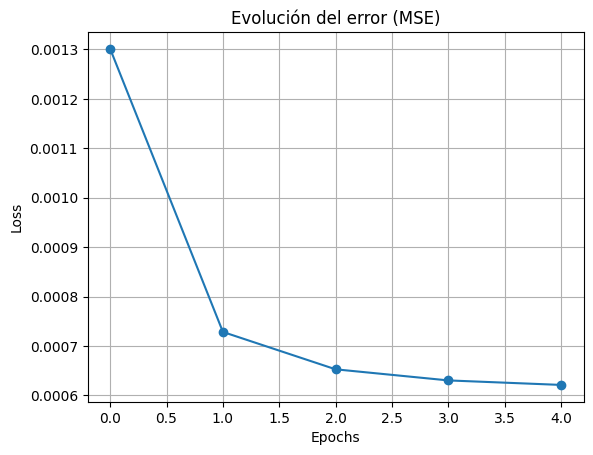

In [7]:
# Gráfico Error vs Epochs

import matplotlib.pyplot as plt

plt.plot(list(range(len(loss_history))), loss_history, marker='o')
plt.title("Evolución del error (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [8]:
# Evaluación en Test

model.eval()
test_loss = 0

with torch.no_grad():
    for X_test, Y_test in test_loader:
        X_test, Y_test = X_test.to(device), Y_test.to(device)
        y_pred = model(X_test)
        loss = criterion(y_pred, Y_test)
        test_loss += loss.item()

print(f"Loss en Test: {test_loss / len(test_loader):.6f}")


Loss en Test: 0.000630


In [9]:
# Guardar epochs, loss_history y Evaluación en un archivo npz
np.savez(
    "metricas_entrenamiento.npz",
    epochs=list(range(len(loss_history))),
    loss=loss_history,
    test_error=test_loss / len(test_loader)
)

In [10]:
model2 = CNN()   # 1. Crear la arquitectura vacía
model2.load_state_dict(torch.load("modelo_final.pth"))  # 2. Cargar pesos
model2.eval()    # 3. Modo evaluación (importante)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=6, bias=True)
)